# ChurnShield — EDA, Feature Engineering, XGBoost, SHAP, Business Cost Matrix

Goal:
- Train churn prediction model on Telco dataset
- Add 4 engineered features
- Optimize XGBoost with Optuna
- Pick threshold using business cost matrix
- Use SHAP to explain predictions

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import optuna
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

In [2]:
BASE_DIR = Path("..")
DATA_PATH = BASE_DIR / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
SAVE_DIR = BASE_DIR / "saved_models"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.shape)
print(df.info())
print(df["Churn"].value_counts(normalize=True))

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

df.drop(columns=["customerID"], inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [5]:
df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[0, 1, 2, 3],
    include_lowest=True,
).astype(int)

df["charge_ratio"] = df["MonthlyCharges"] / (df["TotalCharges"] + 1)

service_cols = [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
]
df["service_count"] = df[service_cols].apply(lambda x: (x != "No").sum(), axis=1)

df["contract_score"] = df["Contract"].map({
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2,
})

df[["tenure_bucket", "charge_ratio", "service_count", "contract_score"]].head()

,tenure_bucket,charge_ratio,service_count,contract_score
0,0,0.967585,3,0
1,2,0.030124,3,1
2,0,0.493358,3,0
3,2,0.022967,5,1
4,0,0.463151,1,0


In [6]:
cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod",
]

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)
feature_cols = [c for c in df_encoded.columns if c != "Churn"]

X = df_encoded[feature_cols]
y = df_encoded["Churn"]

print(X.shape, y.shape)

(7043, 44) (7043,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
scale_pos_weight

np.float64(2.768561872909699)

In [8]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "auc",
        "random_state": 42,
        "n_jobs": -1,
    }

    model = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

study.best_value, study.best_params

[I 2026-05-07 16:24:10,056] A new study created in memory with name: no-name-1ff93514-097f-4f8f-b861-d1080cbfa750
[I 2026-05-07 16:24:10,742] Trial 0 finished with value: 0.8394191204811847 and parameters: {'max_depth': 5, 'learning_rate': 0.06098077702212337, 'n_estimators': 277, 'subsample': 0.8621206101800104, 'colsample_bytree': 0.9776297413547709, 'min_child_weight': 8}. Best is trial 0 with value: 0.8394191204811847.
[I 2026-05-07 16:24:11,496] Trial 1 finished with value: 0.8344347314418723 and parameters: {'max_depth': 7, 'learning_rate': 0.0539983605657843, 'n_estimators': 250, 'subsample': 0.7308645375102967, 'colsample_bytree': 0.8305096150039002, 'min_child_weight': 10}. Best is trial 0 with value: 0.8394191204811847.
[I 2026-05-07 16:24:12,230] Trial 2 finished with value: 0.8388457204227191 and parameters: {'max_depth': 7, 'learning_rate': 0.034964182518162905, 'n_estimators': 239, 'subsample': 0.8716431707969305, 'colsample_bytree': 0.9732622333952841, 'min_child_weight'

(0.8499491804428796,
 {'max_depth': 3,
  'learning_rate': 0.026075005103739207,
  'n_estimators': 154,
  'subsample': 0.7594976563315878,
  'colsample_bytree': 0.8918825967126217,
  'min_child_weight': 9})

In [9]:
model = XGBClassifier(
    **study.best_params,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42,
    n_jobs=1,
)
model.fit(X_train, y_train)

test_probs = model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)
test_auc

0.8485080988917306

In [10]:
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    preds = (test_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    cost = (fn * 2400) + (fp * 200)

    results.append({
        "threshold": round(t, 2),
        "cost": int(cost),
        "fn": int(fn),
        "fp": int(fp),
        "recall": round(recall_score(y_test, preds), 4),
        "precision": round(precision_score(y_test, preds), 4),
    })

cost_df = pd.DataFrame(results)
cost_df

,threshold,cost,fn,fp,recall,precision
0,0.10,151000,2,731,0.9947,0.3373
1,0.15,147800,8,643,0.9786,0.3627
2,0.20,147000,12,591,0.9679,0.3799
3,0.25,150800,18,538,0.9519,0.3982
4,0.30,156200,26,469,0.9305,0.4259
5,0.35,170600,36,421,0.9037,0.4453
6,0.40,196400,51,370,0.8636,0.4661
7,0.45,216400,63,326,0.8316,0.4882
8,0.50,229800,72,285,0.8075,0.5145
9,0.55,262400,89,244,0.7620,0.5388


In [11]:
best_row = cost_df.loc[cost_df["cost"].idxmin()]
best_threshold = float(best_row["threshold"])

default_row = cost_df[cost_df["threshold"] == 0.5].iloc[0]

print("Threshold 0.5 cost:", default_row["cost"])
print("Optimal threshold:", best_threshold)
print("Optimal cost:", best_row["cost"])
print("Cost saved:", default_row["cost"] - best_row["cost"])

Threshold 0.5 cost: 229800.0
Optimal threshold: 0.2
Optimal cost: 147000.0
Cost saved: 82800.0


In [12]:
best_preds = (test_probs >= best_threshold).astype(int)

print("ROC-AUC:", round(test_auc, 4))
print("Recall:", round(recall_score(y_test, best_preds), 4))
print("Precision:", round(precision_score(y_test, best_preds), 4))
print(confusion_matrix(y_test, best_preds))
print(classification_report(y_test, best_preds))

ROC-AUC: 0.8485
Recall: 0.9679
Precision: 0.3799
[[444 591]
 [ 12 362]]
              precision    recall  f1-score   support

           0       0.97      0.43      0.60      1035
           1       0.38      0.97      0.55       374

    accuracy                           0.57      1409
   macro avg       0.68      0.70      0.57      1409
weighted avg       0.82      0.57      0.58      1409



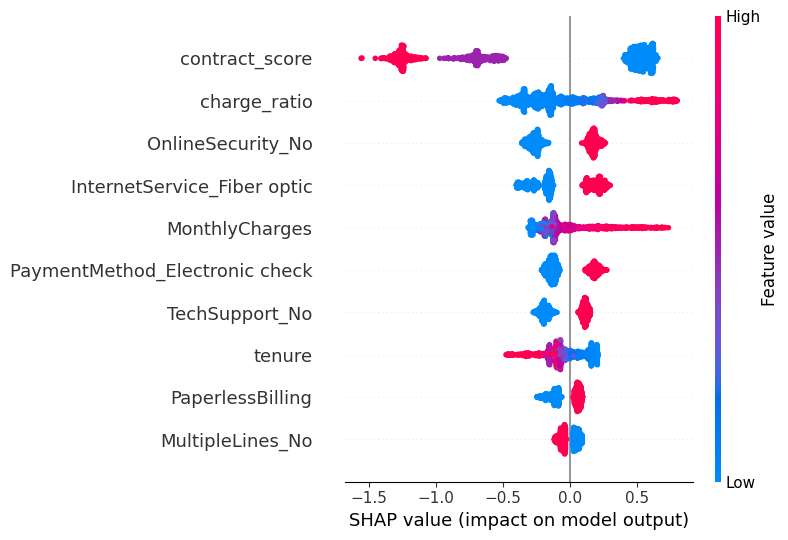

In [13]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=10)

In [14]:
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": np.abs(shap_values).mean(axis=0)
}).sort_values("importance", ascending=False)

importance_df.head(5)

,feature,importance
12,contract_score,0.734122
10,charge_ratio,0.264368
19,OnlineSecurity_No,0.220079
17,InternetService_Fiber optic,0.212819
7,MonthlyCharges,0.184310


In [15]:
sample_customer = pd.DataFrame([{
    "tenure": 2,
    "MonthlyCharges": 85.0,
    "TotalCharges": 170.0,
    "gender": 1,
    "SeniorCitizen": 0,
    "Partner": 0,
    "Dependents": 0,
    "PhoneService": 1,
    "PaperlessBilling": 1,
    "tenure_bucket": 0,
    "charge_ratio": 85.0 / (170.0 + 1),
    "service_count": 3,
    "contract_score": 0,
    "MultipleLines_No": 1,
    "MultipleLines_Yes": 0,
    "InternetService_DSL": 0,
    "InternetService_Fiber optic": 1,
    "InternetService_No": 0,
    "OnlineSecurity_No": 1,
    "OnlineSecurity_Yes": 0,
    "OnlineBackup_No": 1,
    "OnlineBackup_Yes": 0,
    "DeviceProtection_No": 1,
    "DeviceProtection_Yes": 0,
    "TechSupport_No": 1,
    "TechSupport_Yes": 0,
    "StreamingTV_No": 1,
    "StreamingTV_Yes": 0,
    "StreamingMovies_No": 1,
    "StreamingMovies_Yes": 0,
    "Contract_Month-to-month": 1,
    "Contract_One year": 0,
    "Contract_Two year": 0,
    "PaymentMethod_Bank transfer (automatic)": 0,
    "PaymentMethod_Credit card (automatic)": 0,
    "PaymentMethod_Electronic check": 1,
    "PaymentMethod_Mailed check": 0,
}])

for col in X_train.columns:
    if col not in sample_customer.columns:
        sample_customer[col] = 0

sample_customer = sample_customer[X_train.columns]

sample_prob = model.predict_proba(sample_customer)[:, 1][0]
sample_prob

np.float32(0.85801274)

In [16]:
model_data = {
    "model": model,
    "threshold": best_threshold,
    "feature_cols": list(X_train.columns),
}
joblib.dump(model_data, SAVE_DIR / "churn_model.pkl")

with open(SAVE_DIR / "feature_names.json", "w") as f:
    json.dump(list(X_train.columns), f, indent=2)

print("Saved model and feature names")

Saved model and feature names
